[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NDesassis/notebooks/blob/main/unconditional_generation_solution.ipynb)

Author: Gabriel V. Cardoso

https://gabrielvc.github.io/

# Unconditional generation

The goal of this notebook is to implement the backward procedure of the diffusion generative model.

## Recall: Forward process

The forward process is the Markov Chain defined as

$$X_{t+1} = X_{t} + \sigma_t Z_t\;,$$

with $X_0 \sim p_{0}$ and $Z_t$ iid Standard gaussian distributions.


## Recall: Backward process

The backward process is the Markov chain that best approximates the joint law of the forward process, which is characterized by the two moments $\mathbb{E}[X_t | X_{t+1}=x]$ and $\mathbb{V}[X_t | X_{t+1}=x]$. We consider that we have a denoiser network $D_{\theta}$ that approximates $\mathbb{E}[X_t | X_{t+1}=x]$.

In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Callable
from tqdm import tqdm
import math

In [2]:
def ddpm(
    sigmas: torch.Tensor,
    initial_samples: torch.Tensor,
    denoiser_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
) -> torch.Tensor:
    # Implement your code here!
    samples = initial_samples
    for sigma_tm1, sigma_t in tqdm(zip(reversed(sigmas[:-1]), reversed(sigmas[1:]))):
        denoised_x0 = denoiser_fn(samples, sigma_t)
        mean = denoised_x0 + ((sigma_tm1/sigma_t)**2) * (samples - denoised_x0)
        std = (((sigma_tm1/sigma_t)**2) * (sigma_t**2 - sigma_tm1**2))**.5
        samples = mean + std * torch.randn_like(mean)
    return samples


## First example: Mixture of Gaussians

We are first going to use a Mixture of Gaussians as the target distribution. This is particularly interesting from the visualization point of view and also because we have the "true score" function.


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


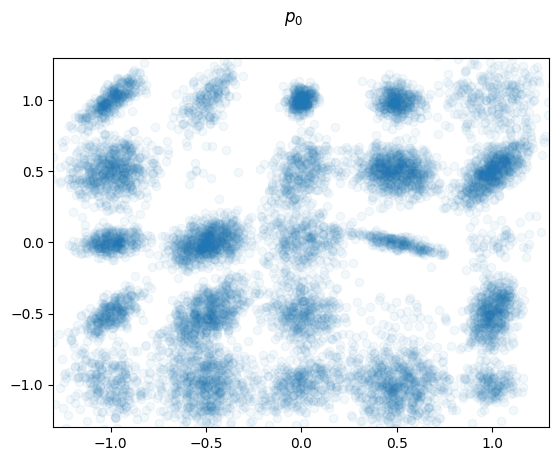

In [3]:
def get_random_unitary(n=20, dim=2):
    seeds = torch.randn((n, dim, dim))
    U, _, _ = torch.linalg.svd(seeds)
    S = torch.stack([torch.diag(s) for s in torch.rand((n, dim))])
    return U @ S @ U.mT

means = torch.stack(
    torch.meshgrid(
        torch.linspace(-1, 1, 5),
        torch.linspace(-1, 1, 5),
    )
).flatten(1, 2).T
covars = get_random_unitary(n=means.shape[0], dim=means.shape[1])*(0.15**2)
weights = torch.rand(means.shape[0])
weights = weights / weights.sum()
def make_noised_mixture(means, covars, weights, sigma):
    return torch.distributions.MixtureSameFamily(
        component_distribution=torch.distributions.MultivariateNormal(
            loc=means, covariance_matrix=covars + torch.eye(covars.shape[-1])[None]*sigma**2
        ),
        mixture_distribution=torch.distributions.Categorical(probs=weights)
    )

def denoiser_fn_mixture(x, sigma):
    score = torch.func.grad(lambda y: make_noised_mixture(means, covars, weights, sigma).log_prob(y).sum())(x)
    return x + (sigma**2) * score

fig, ax = plt.subplots(1, 1)
fig.suptitle(r"$p_{0}$")
ax.scatter(*make_noised_mixture(means, covars, weights, sigma=0).sample((10_000,)).T, alpha=.05)
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
fig.show()

999it [00:17, 58.34it/s]


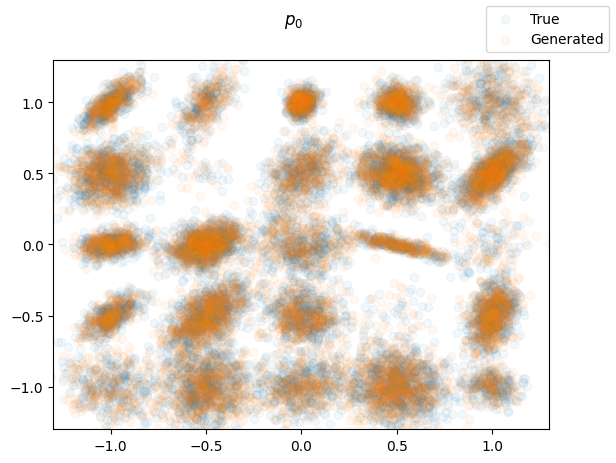

In [4]:
sigmas = torch.linspace(0.002**(1/3), 80**(1/3), 1000)**3
generated_samples = ddpm(
    initial_samples = torch.randn((10_000, 2))*((sigmas[-1]**2 + 1)**.5),
    sigmas = sigmas,
    denoiser_fn=denoiser_fn_mixture
)
fig, ax = plt.subplots(1, 1)
fig.suptitle(r"$p_{0}$")
ax.scatter(*make_noised_mixture(means, covars, weights, sigma=0).sample((10_000,)).T, alpha=.05, label="True")
ax.scatter(*generated_samples.T, alpha=.05, label="Generated")
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
fig.legend()
fig.show()

In [1]:
from diffusers import UNet2DModel, DDPMScheduler

model_id = "google/ddpm-celebahq-256"
scheduler = DDPMScheduler.from_pretrained(model_id)
model = UNet2DModel.from_pretrained(model_id).to("cuda").eval().requires_grad_(False)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

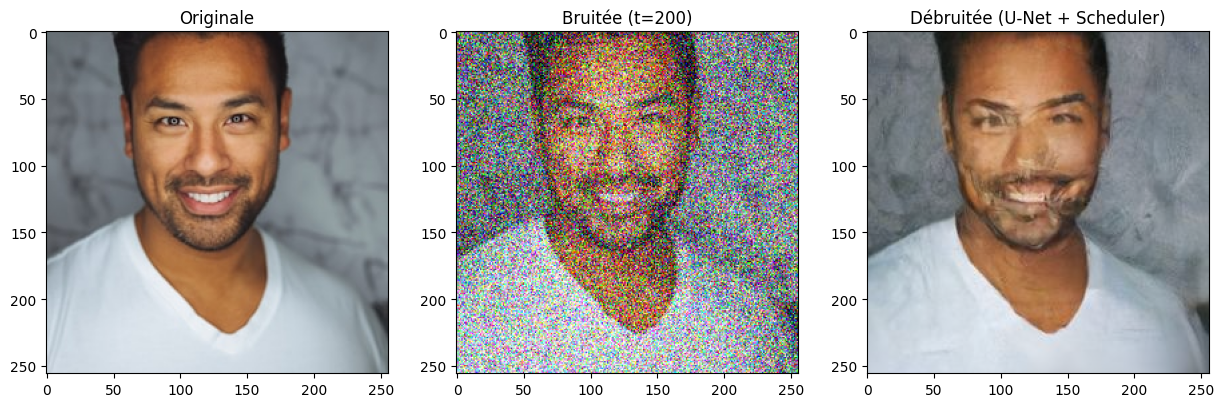

In [6]:
import torch
import requests
from PIL import Image
from io import BytesIO
from torchvision import transforms
import matplotlib.pyplot as plt

# 1. Chargement et Prétraitement de l'image
url = "https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d?w=256&h=256&fit=crop"
image_raw = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Crucial pour le U-Net (plage -1 à 1)
])

input_tensor = preprocess(image_raw).unsqueeze(0).to("cuda")

# 2. Ajout du bruit (Forward Diffusion)
# On choisit une étape de bruitage (ex: 300 sur 1000 pour un bruit modéré)
timestep_idx = 200
noise = torch.randn_like(input_tensor)
noisy_image = scheduler.add_noise(input_tensor, noise, torch.tensor([timestep_idx]).to("cuda"))

# 3. Débruitage Itératif (Sampling Loop)
# On ne fait pas "Image - Bruit", on laisse le scheduler raffiner l'image pas à pas
scheduler.set_timesteps(num_inference_steps=50)
sample = noisy_image

# On retrouve l'indice de départ correspondant à notre bruitage
start_step = 50 - int((timestep_idx / 1000) * 50)

for t in scheduler.timesteps[start_step:]:
    with torch.no_grad():
        # Le U-Net prédit le bruit résiduel
        noise_pred = model(sample, t).sample
        # Le Scheduler retire une fraction du bruit et lisse le résultat
        sample = scheduler.step(noise_pred, t, sample).prev_sample

# 4. Affichage
def postprocess(tensor):
    tensor = (tensor.detach().cpu().clamp(-1, 1) + 1) / 2
    return tensor.permute(0, 2, 3, 1).squeeze().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(postprocess(input_tensor)); ax[0].set_title("Originale")
ax[1].imshow(postprocess(noisy_image)); ax[1].set_title(f"Bruitée (t={timestep_idx})")
ax[2].imshow(postprocess(sample)); ax[2].set_title("Débruitée (U-Net + Scheduler)")
plt.show()

In [5]:


def denoiser_fn_hf(x, sigma):
    # This part belows convert the variance exploding framework to the variance preserving.

    eq_alpha = 1 / (sigma**2 + 1)
    get_closest = torch.abs(scheduler.alphas_cumprod - eq_alpha).argmin().item()
    closest_alpha = scheduler.alphas_cumprod[get_closest]
    eq_x = x / (sigma**2 + 1)**.5

    out_model = model(eq_x, get_closest).sample
    pred_x0 = ((eq_x  -  ((1 - closest_alpha)**.5)*out_model) / (closest_alpha**.5)).clip(-1, 1)
    return pred_x0

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

In [7]:
sigmas = (1/scheduler.alphas_cumprod - 1)**.5
generated_samples = ddpm(
    initial_samples = torch.randn((1, 3, 256, 256), device="cuda")*((sigmas[-1]**2 + 1)**.5),
    sigmas = sigmas,
    denoiser_fn=denoiser_fn_hf
)

999it [02:15,  7.38it/s]


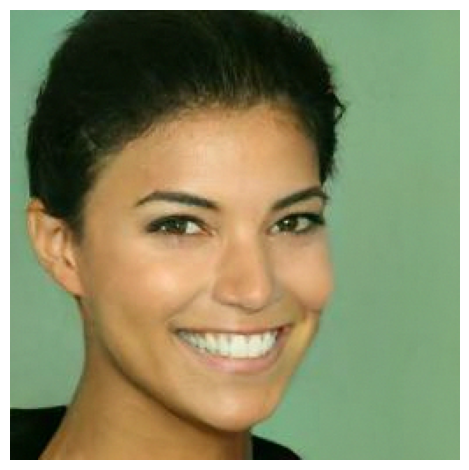

In [8]:
fig, ax = plt.subplots(1, 1)
ax.imshow(((generated_samples[0] + 1)/2).permute(1, 2, 0).cpu())
ax.set_axis_off()
fig.tight_layout()
fig.show()